# Exploração do dataset MedQuAD

Um breve tratamento e exploração dos pares de perguntas e respostas MedQuAD classificados.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv(
    "assets/QA-TestSet-LiveQA-Med-Qrels-2479-Answers/All-qrels_LiveQAMed2017-TestQuestions_2479_Judged-Answers.txt",
    # Apesar de ser um arquivo .txt, cada linha é um registro separado por espaço
    sep="\\s",
    engine="python",
    header=None,
    names=["qid", "score", "docid"],
)

df.head()

,qid,score,docid
0,1,1-Incorrect,ADAM_0003147_Sec1.txt
1,1,1-Incorrect,ADAM_0003147_Sec2.txt
2,1,2-Related,ADAM_0002818_Sec2.txt
3,1,2-Related,ADAM_0002818_Sec7.txt
4,1,2-Related,ADAM_0002818_Sec9.txt


Vamos verificar a distribuição de pares considerando sua classificação.

<Axes: xlabel='score'>

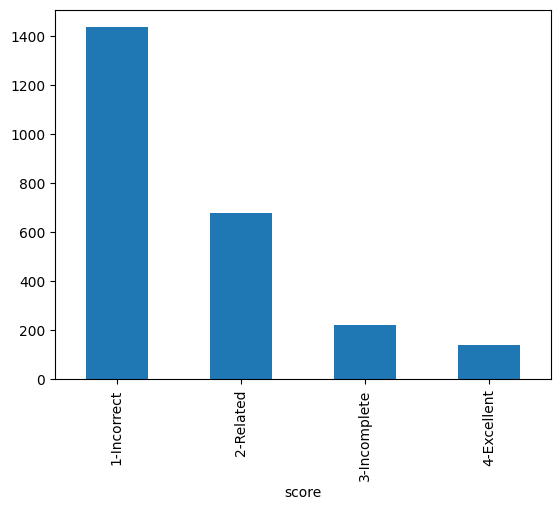

In [56]:
df["score"].value_counts().plot.bar()

O dataset é dominado por pares de perguntas e respostas incorretas, com menos de 200 exemplos corretos e pouco mais de 200 parcialmente respondidos (incompletos.)

Outra coisa a ser verifica é a unicidade dos registros.

In [75]:
df[df.duplicated(subset=["docid", "qid"], keep=False)].sort_values(by=["qid", "docid"])

,qid,score,docid
2,1,2-Related,ADAM_0002818_Sec2.txt
11,1,3-Incomplete,ADAM_0002818_Sec2.txt
6,1,2-Related,GARD_0004450_Sec3.txt
14,1,3-Incomplete,GARD_0004450_Sec3.txt
118,6,1-Incorrect,ADAM_0002332_Sec2.txt
...,...,...,...
2444,103,2-Related,ADAM_0003341_Sec1.txt
2445,103,2-Related,ADAM_0003826_Sec1.txt
2448,103,3-Incomplete,ADAM_0003826_Sec1.txt
2446,103,2-Related,MPlusHealthTopics_0000105_Sec1.txt


Pode ser constatado que o mesmo `qid` aparece mais de uma vez com a mesma resposta e ainda assim ter uma classificação diferente. Vamos voltar a investigar isso depois de unir o restante do datasete contendo as perguntas e respostas em forma de texto.

## Reconstruindo o dataset

Para poder avaliar se usamos apenas as respostas de classificação 4 ou combinamos com classificação 3, vamos enriquecer o dataset com o conteúdo efetivo das perguntas e respostas.

In [58]:
df_qa = pd.read_csv(
    "assets/QA-TestSet-LiveQA-Med-Qrels-2479-Answers/All-2479-Answers-retrieved-from-MedQuAD.csv"
)

df_qa.head()

,AnswerID,Answer
0,ADAM_0003147_Sec1.txt,Question: What is (are) Polycystic ovary syndr...
1,ADAM_0003147_Sec2.txt,Question: What causes Polycystic ovary syndrom...
2,ADAM_0002818_Sec2.txt,Question: What causes Noonan syndrome ?\nURL: ...
3,ADAM_0002818_Sec7.txt,Question: What are the complications of Noonan...
4,ADAM_0002818_Sec9.txt,Question: How to prevent Noonan syndrome ?\nUR...


A coluna "Answer" na verdade contém três informações: Questions, URL e Answer (Pergunta, URL de onde foi extraída a resposta, e a Resposta efetivamente).

Vamos separar estas colunas pois precisaremos traduzir as perguntas e respostas para o português. Não queremos desperdicar tokens traduzindo URLs e queremos maior controle sobre como apresentaremos exemplos de interações no nosso fine tuning.

In [59]:
df_qa["Original_QA"] = df_qa["Answer"]

import re

# Ideia: vamos verificar se todos os pares de pergunta e resposta possuem uma URL separando cada elemento.

# Filtra apenas as linhas onde a coluna 'Answer' contém o padrão "URL: .+\n"
mask = df_qa["Answer"].str.contains(r"URL: .+\n", regex=True)
df_qa_with_url = df_qa[mask]

# Compara o número total de registros com o número de registros que correspondem ao padrão
total_records = len(df_qa)
matching_records = df_qa_with_url.shape[0]
print(f"Número total de registros: {total_records}")
print(f"Número de registros com padrão 'URL: .+\\n': {matching_records}")

assert total_records == matching_records

Número total de registros: 2479
Número de registros com padrão 'URL: .+\n': 2479


Vamos usar a linha "URL:" como separador de "Question" e "Answer".

In [60]:
# Confirmado; procedendo usando a linha da URL como separador.

df_qa[["Question", "Answer"]] = (
    df_qa["Original_QA"]
    .str.split(r"URL: .+\n", expand=True)
    # e removendo os prefixos Question: e Answer:
    .apply(lambda x: x.str.replace(r"^(Question|Answer):\s*", "", regex=True).str.strip())
)
df_qa.head()

,AnswerID,Answer,Original_QA,Question
0,ADAM_0003147_Sec1.txt,Polycystic ovary syndrome is a condition in wh...,Question: What is (are) Polycystic ovary syndr...,What is (are) Polycystic ovary syndrome ? (Als...
1,ADAM_0003147_Sec2.txt,PCOS is linked to changes in hormone levels th...,Question: What causes Polycystic ovary syndrom...,What causes Polycystic ovary syndrome ? (Also ...
2,ADAM_0002818_Sec2.txt,Noonan syndrome is linked to defects in severa...,Question: What causes Noonan syndrome ?\nURL: ...,What causes Noonan syndrome ?
3,ADAM_0002818_Sec7.txt,- Buildup of fluid in tissues of body (lymphed...,Question: What are the complications of Noonan...,What are the complications of Noonan syndrome ?
4,ADAM_0002818_Sec9.txt,Couples with a family history of Noonan syndro...,Question: How to prevent Noonan syndrome ?\nUR...,How to prevent Noonan syndrome ?


Por fim, vamos unir os dois dataframes através de seus índices posicionais.

In [61]:
merged_df = df_qa.copy()
merged_df[df.columns] = df
merged_df.drop(columns=["docid", "Original_QA"], inplace=True)

merged_df

,AnswerID,Answer,Question,qid,score
0,ADAM_0003147_Sec1.txt,Polycystic ovary syndrome is a condition in wh...,What is (are) Polycystic ovary syndrome ? (Als...,1,1-Incorrect
1,ADAM_0003147_Sec2.txt,PCOS is linked to changes in hormone levels th...,What causes Polycystic ovary syndrome ? (Also ...,1,1-Incorrect
2,ADAM_0002818_Sec2.txt,Noonan syndrome is linked to defects in severa...,What causes Noonan syndrome ?,1,2-Related
3,ADAM_0002818_Sec7.txt,- Buildup of fluid in tissues of body (lymphed...,What are the complications of Noonan syndrome ?,1,2-Related
4,ADAM_0002818_Sec9.txt,Couples with a family history of Noonan syndro...,How to prevent Noonan syndrome ?,1,2-Related
...,...,...,...,...,...
2474,MPlusDrugs_0000553_Sec5.txt,"Before you start to take glimepiride, ask you ...",What should I do if I forget a dose of Glimepi...,104,2-Related
2475,MPlusDrugs_0000553_Sec6.txt,This medication may cause changes in your bloo...,What are the side effects or risks of Glimepir...,104,2-Related
2476,MPlusDrugs_0000553_Sec8.txt,"In case of overdose, call your local poison co...",What to do in case of emergency or overdose of...,104,2-Related
2477,MPlusDrugs_0000553_Sec9.txt,Keep all appointments with your doctor and the...,What other information should I know about Gli...,104,2-Related


## Avaliando respostas incompletas

Agora sim, vamos avaliar alguns exemplos de respostas incompletas antes de determinar se as usaremos também no fine tuning ou não.

In [62]:
with pd.option_context("display.max_colwidth", 500):
    display(
        merged_df[merged_df["score"] == "3-Incomplete"].sample(n=5, random_state=42)
    )

,AnswerID,Answer,Question,qid,score
41,MPlusDrugs_0001309_Sec5.txt,"Zolmitriptan may cause side effects. Tell your doctor if any of these symptoms are severe or do not go away: - feeling warm or cold - drowsiness - dry mouth - nausea - heartburn - sweating - dizziness or faintness Some side effects can be serious. If you experience any of these symptoms, call your doctor immediately or get emergency medical treatment: - pain, tightness, pressure, or heaviness in the chest, throat, neck, or jaw - slow or difficult speech - weakness or numbness of...",What are the side effects or risks of Zolmitriptan ?,2,3-Incomplete
1065,MPlusDrugs_0001016_Sec2.txt,"Prednisone comes as a tablet, a solution (liquid), and a concentrated solution to take by mouth. Prednisone is usually taken with food one to four times a day or once every other day. Your doctor will probably tell you to take your dose(s) of prednisone at certain time(s) of day every day. Your personal dosing schedule will depend on your condition and on how you respond to treatment. Follow the directions on your prescription label carefully, and ask your doctor or pharmacist to explain any...",How should Prednisone be used and what is the dosage ?,42,3-Incomplete
1556,MPlusDrugs_0000356_Sec4.txt,"Diclofenac comes as a tablet, and liquid-filled capsule, a hard gelatin capsule, an extended-release (long-acting) tablet, a delayed-release (releases medication in the intestine) tablet, and as packets of powder for solution (to be mixed with water) and take by mouth. Diclofenac liquid-filled capsules are usually taken 4 times a day and diclofenac hard gelatin capsules are usually taken three times a day on an empty stomach. Diclofenac extended-release tablets are usually taken once a day, ...",How should Diclofenac be used and what is the dosage ?,62,3-Incomplete
1765,GHR_0000563_Sec5.txt,These resources address the diagnosis or management of Klippel-Trenaunay syndrome: - Cincinnati Children's Hospital Medical Center - Cleveland Clinic - Genetic Testing Registry: Klippel Trenaunay syndrome - Seattle Children's Hospital These resources from MedlinePlus offer information about the diagnosis and management of various health conditions: - Diagnostic Tests - Drug Therapy - Surgery and Rehabilitation - Genetic Counseling - Palliative Care),What are the treatments for Klippel-Trenaunay syndrome ? (Also called: angio-osteohypertrophy syndrome; congenital dysplastic angiopathy; Klippel-Trenaunay disease; Klippel-Trenaunay-Weber syndrome; KTS; KTW syndrome),73,3-Incomplete
2447,ADAM_0001052_Sec1.txt,"Summary : A CSF cell count is a test to measure the number of red and white blood cells that are in cerebrospinal fluid (CSF). CSF is a clear fluid that in the space around the spinal cord and brain.\n\nHow the Test is Performed : A lumbar puncture (spinal tap) is the most common way to collect this sample. Rarely, other methods are used for collecting CSF such as: - Cisternal puncture - Ventricular puncture - Removal of CSF from a tube that is already in the CSF, such as a shunt or ventr...",Do you have information about CSF cell count,103,3-Incomplete


Mmm... talvez seja melhor ignorar estas respostas. Não apenas são incompletas, como trazem muita informação que pode sobrecarregar o médico durante o atendimento, indo contra o propósito de um assistente dessa natureza.

## Limpando o dataset

Uma coisa chamou atenção: há menções a números dos Estados Unidos. Vamos verificar se no conjunto de respostas completas há menções a este país e avaliar se precisamos de algum tratamento nesse sentido.

In [63]:
df_excellent_but_us = merged_df[
    (merged_df["score"] == "4-Excellent")
    & (merged_df["Answer"].str.contains(r"United\s+States", regex=True))
]

print(f"Número de respostas perfeitas que mencionam os EUA: {df_excellent_but_us.shape[0]}")

with pd.option_context("display.max_colwidth", None, "display.max_rows", 20):
    display(
        df_excellent_but_us.head(20)
    )


Número de respostas perfeitas que mencionam os EUA: 5


AnswerID  \
1372  ADAM_0001941_Sec2.txt   
1430   CDC_0000212_Sec4.txt   
1697  ADAM_0000920_Sec2.txt   
2032  ADAM_0000642_Sec1.txt   
2419  ADAM_0000288_Sec2.txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

Dentro das respostas consideradas excelentes, há apenas 5 menções aos Estados Unidos - históricos de epidemias, estatísticas e menções a órgãos reguladores do país norte-americano. Como são poucos registros, vale seguir adiante com eles.

Vamos criar um dataframe com as respostas escolhidas (4-Excellent).

In [64]:
df_excellent = merged_df[merged_df["score"] == "4-Excellent"]
df_excellent.head()

,AnswerID,Answer,Question,qid,score
86,ADAM_0003820_Sec4.txt,The doctor or nurse will examine you. Tests th...,How to diagnose Syphilis - primary ? (Also cal...,4,4-Excellent
87,ADAM_0003820_Sec5.txt,"Syphilis can be treated with antibiotics, such...",What are the treatments for Syphilis - primary...,4,4-Excellent
88,ADAM_0003820_Sec9.txt,"If you are sexually active, practice safe sex ...",How to prevent Syphilis - primary ? (Also call...,4,4-Excellent
131,ADAM_0002332_Sec2.txt,Injury to the laryngeal nerves is uncommon. W...,What causes Laryngeal nerve damage ? (Also cal...,6,4-Excellent
220,ADAM_0001766_Sec2.txt,"GPA mainly affects blood vessels in the nose, ...",What causes Granulomatosis with polyangiitis ?...,9,4-Excellent


Considerando que o `qid` aparece repetidamente, vamos verificar duplicidade dos registros considerando as colunas "Question", "Answer" e "score".

In [65]:
df_excellent[df_excellent.duplicated(subset=["Question", "Answer", "score"])]

,AnswerID,Answer,Question,qid,score
1927,NIHSeniorHealth_0000062_Sec1.txt,Shingles is a painful rash that develops on on...,What is (are) Shingles ?,79,4-Excellent


Ah! Um registro apenas. Vamos remover.

In [66]:
df_excellent = df_excellent.drop_duplicates(subset=["Question", "Answer", "score"])

Estamos aceitando que no dataset as perguntas aparecem mais de uma vez com respostas diferentes. O `qid` provavelmente se refere a uma categoria de perguntas no dataset de perguntas usado para a avaliação do MedQuAD.

In [67]:
with pd.option_context("display.max_colwidth", 500):
    display(
        df_excellent[df_excellent.duplicated(subset="Question", keep=False)].sort_values(
            by="Question"
        )
    )

,AnswerID,Answer,Question,qid,score
1926,NIHSeniorHealth_0000062_Sec15.txt,"Yes. In May 2006, the U.S. Food and Drug Administration approved a vaccine to prevent shingles in people age 60 and older. The vaccine, called Zostavax, is designed to boost the immune system and protect older adults from getting shingles later on. Even if you have had shingles, you can still get the shingles vaccine to help prevent future occurrences of the disease. There is no maximum age for getting the vaccine, and only a single dose is recommended. The shingles vaccine is NOT recommende...",How to prevent Shingles ?,79,4-Excellent
1928,NIHSeniorHealth_0000062_Sec3.txt,"A Vaccine for Adults 60 and Older In May 2006, the U.S. Food and Drug Administration approved a vaccine (Zostavax) to prevent shingles in people age 60 and older. The vaccine is designed to boost the immune system and protect older adults from getting shingles later on. Even if you have had shingles, you can still get the shingles vaccine to help prevent future occurrences of the disease. There is no maximum age for getting the vaccine, and only a single dose is recommended. In a clinical tr...",How to prevent Shingles ?,79,4-Excellent
2303,NHLBI_0000058_Sec2.txt,"Coronary Heart Disease\n \nA heart attack happens if the flow of oxygen-rich blood to a section of heart muscle suddenly becomes blocked and the heart can't get oxygen. Most heart attacks occur as a result of coronary heart disease (CHD).\n \nCHD is a condition in which a waxy substance called plaque builds up inside of the coronary arteries. These arteries supply oxygen-rich blood to your heart.\n \nWhen plaque builds up in the arteries, the cond...",What causes Heart Attack ?,96,4-Excellent
2304,NIHSeniorHealth_0000033_Sec3.txt,"Most heart attacks are caused by a blood clot that blocks one of the coronary arteries, the blood vessels that bring blood and oxygen to the heart muscle. When blood cannot reach part of your heart, that area starves for oxygen. If the blockage continues long enough, cells in the affected area die. The Most Common Cause Coronary heart disease (CHD)is the most common underlying cause of a heart attack. CHD, also called coronary artery disease, is the hardening and narrowing of the coronary ar...",What causes Heart Attack ?,96,4-Excellent
2305,NIHSeniorHealth_0000033_Sec8.txt,"Coronary heart disease, or CHD, is the most common underlying cause of a heart attack. Coronary arteries are the blood vessels that bring blood and oxygen to the heart muscle. Most heart attacks are caused by a blood clot that blocks one of the coronary arteries. When blood cannot reach part of your heart, that area starves for oxygen. If the blockage continues long enough, cells in the affected area die.)",What causes Heart Attack ?,96,4-Excellent
1973,NIHSeniorHealth_0000015_Sec16.txt,"Heart disease and stroke are the leading causes of death for people with diabetes. Controlling the ABCs of diabetes -- your blood glucose, your blood pressure, and your cholesterol, as well as stopping smoking -- can help prevent these and other complications from diabetes. - A is for the A1C test - B is for Blood pressure - C is for Cholesterol. A is for the A1C test B is for Blood pressure C is for Cholesterol. - The A1C test (A-one-C) shows you what your blood glucose has been over t...",What is (are) Diabetes ?,82,4-Excellent
1974,NIHSeniorHealth_0000015_Sec18.txt,"People with diabetes should - do aerobic activities, such as brisk walking, which use the bodys large muscles to make the heart beat faster. The large muscles are those of the upper and lower arms and legs and those that control head, shoulder, and hip movements. - do activities to strengthen muscles and bone, such as sit-ups or lifting weights. Aim for two times a week. - stretch to increase flexibility, lower stress, and help prevent muscle soreness after physical activity. do aerobic ...",What is (are) Diabetes ?,82,4-Excellent
1975,NIHSeniorHealth_0000015_Sec1.txt,Too Much 

In [68]:
df_excellent.shape[0]

141

Pronto! Apesar do número final relativamente baixo (apenas 141 pares), podemos prosseguir com a tradução do dataset filtrado, encontrado na variável `df_excellent`.

# Traduzindo o dataset

Vamos usar uma LLM para traduzir as perguntas para o portugês brasileiro, preservando o tom médico.

Começaremos testando com apenas um par.

In [69]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

MODEL= "gemma4:e4b-it-q4_K_M"

llm = ChatOllama(model=MODEL, temperature=0.1)

translation_prompt = ChatPromptTemplate.from_messages([
    (   
        "system", 
        "Você é um tradutor de textos médicos."
        "Seu objetivo é traduzir as perguntas e respostas para o português brasileiro, preservando o tom médico."
        "Responda diretamente, sem explicações."
        "Responda com 'Pergunta:' e 'Resposta:'"
    ),
    (
        "user",
        "Question: {question}"
        "-----"
        "Answer: {answer}"
    ),
])

translation_chain = translation_prompt | llm | StrOutputParser()

question = df_excellent["Question"].iloc[0]
answer = df_excellent["Answer"].iloc[0]

result = translation_chain.invoke({
    "question": question,
    "answer": answer
})

print(f"Original question: {question}")
print(f"Original answer: {answer}")
print(f"Translated:\n{result}")

Original question: How to diagnose Syphilis - primary ? (Also called: Primary syphilis; Secondary syphilis; Late syphilis; Tertiary syphilis)
Original answer: The doctor or nurse will examine you. Tests that may be done include:  - Examination of fluid from sore  - Echocardiogram, aortic angiogram, and cardiac catheterization to look at the major blood vessels and the heart  - Spinal tap and examination of spinal fluid  - Blood tests to screen for syphillis bacteria (RPR, VDRL, or TRUST)    If the RPR, VDRL, or TRUST tests are positive, one of the following tests will be needed to confirm the diagnosis:   - FTA-ABS (fluorescent treponemal antibody test)  - MHA-TP  - TP-EIA  - TP-PA)
Translated:
Pergunta: Como diagnosticar sífilis primária? (Também chamado de: Sífilis primária; Sífilis secundária; Sífilis tardia; Sífilis terciária)
Resposta: O médico ou enfermeiro fará um exame físico. Os testes que podem ser realizados incluem: - Exame de fluido da lesão - Ecocardiograma, angiograma aó

Parece satisfatório! Traduziu corretamente "spinal tap" para "punção lombar", ao invés de algo mais literal como "toque na espinha", o que pode indicar que o modelo base (Gemma4) possui algum corpus médico em seu treinamento inicial.

Vamos verificar as respostas que o modelo fundacional fornece antes do fine tuning para fins comparativos.

Mas antes, vamos criar um OutputParser customizado para facilitar comparações e extração das perguntas e respostas traduzidas em larga escala.

## OutputParser customizado

In [70]:
from dataclasses import dataclass
from langchain_core.output_parsers import BaseOutputParser

@dataclass
class QAOutput:
    pergunta: str
    resposta: str

    def __repr__(self):
        return f"Pergunta : {self.pergunta}\nResposta : {self.resposta}"

# ── Custom parser ──────────────────────────────────────────────
class PerguntaRespostaParser(BaseOutputParser[QAOutput]):
    """Parses output expected in 'Pergunta: ...\nResposta: ...' format."""

    def parse(self, text: str) -> QAOutput:
        match = re.search(
            r"Pergunta:\s*(.+?)\s*Resposta:\s*(.+)",
            text,
            re.IGNORECASE | re.DOTALL,
        )
        if not match:
            raise ValueError(f"Could not parse output:\n{text}")
        return QAOutput(pergunta=match.group(1).strip(), resposta=match.group(2).strip())

    @property
    def _type(self) -> str:
        return "pergunta_resposta_parser"

Executando o prompt anterior, desta vez com nosso parser para capturar a pergunta traduzida na saída.

In [71]:
translation_chain = translation_prompt | llm | PerguntaRespostaParser()

result = translation_chain.invoke({
    "question": question,
    "answer": answer
})

print(f"Original question: {question}")
print(f"Original answer: {answer}")

pergunta, resposta = result.pergunta, result.resposta
print(f"Pergunta: {pergunta}")
print(f"Resposta: {resposta}")

Original question: How to diagnose Syphilis - primary ? (Also called: Primary syphilis; Secondary syphilis; Late syphilis; Tertiary syphilis)
Original answer: The doctor or nurse will examine you. Tests that may be done include:  - Examination of fluid from sore  - Echocardiogram, aortic angiogram, and cardiac catheterization to look at the major blood vessels and the heart  - Spinal tap and examination of spinal fluid  - Blood tests to screen for syphillis bacteria (RPR, VDRL, or TRUST)    If the RPR, VDRL, or TRUST tests are positive, one of the following tests will be needed to confirm the diagnosis:   - FTA-ABS (fluorescent treponemal antibody test)  - MHA-TP  - TP-EIA  - TP-PA)
Pergunta: Como diagnosticar sífilis primária? (Também chamado de: Sífilis primária; Sífilis secundária; Sífilis tardia; Sífilis terciária)
Resposta: O médico ou enfermeiro fará um exame físico. Os testes que podem ser realizados incluem: - Exame de fluido da lesão - Ecocardiograma, angiografia aórtica e cat

## Avaliando o modelo base

Vamos fornecer um system prompt que se aproxime do que desejamos usar na solução final para verificar como o modelo base se comporta antes do fine tuning.

In [72]:
from IPython.display import Markdown, display

assistant_prompt = ChatPromptTemplate.from_messages([
    (   
        "system", 
        "Você é um assistente clínico de apoio a médicos no Brasil."
        "Recomende mas não prescreva medicamentos, doses ou esquemas terapêuticos específicos: o médico responsável decide."
        "Evite inventar dados clínicos."
        "Responda em português do Brasil, de forma objetiva e profissional, apenas com informações relevantes à interação."
    ),
    (
        "user",
        "{question}"
    ),
])

# usamos o parser padrão aqui
assistant_chain = assistant_prompt | llm | StrOutputParser()

result = assistant_chain.invoke({
    "question": pergunta,
})

print(f"Pergunta: {pergunta}")

# exibindo a saída em markdown pois este modelo tende a usar este padrão
print(f"Resposta: (markdown)")
display(Markdown(result))


Pergunta: Como diagnosticar sífilis primária? (Também chamado de: Sífilis primária; Sífilis secundária; Sífilis tardia; Sífilis terciária)
Resposta: (markdown)


O diagnóstico da sífilis é geralmente feito por uma combinação de avaliação clínica e exames laboratoriais (sorologia).

É importante notar que a sífilis é uma doença progressiva, e o diagnóstico laboratorial é crucial para determinar a fase da infecção e a atividade da doença.

### 1. Avaliação Clínica (Sinais e Sintomas)

O diagnóstico primário é fortemente sugerido pela presença de uma **lesão de cancro** (chancre) no local de entrada da bactéria (geralmente genitais, mas pode ocorrer em outras mucosas).

*   **Características do Cancro:** É uma úlcera indolor, firme, com bordas elevadas e geralmente única.
*   **Diferencial:** O médico deve sempre diferenciar o cancro sifilítico de outras lesões ulcerativas (como herpes genital, chancroide ou úlceras traumáticas).

### 2. Exames Laboratoriais (Sorologia)

A sorologia é o método padrão-ouro para o diagnóstico de sífilis, pois detecta anticorpos produzidos pelo organismo em resposta à infecção.

**A. Testes Não Treponêmicos (Screening e Monitoramento)**
Estes testes detectam anticorpos contra lipídeos e não são específicos para *Treponema pallidum*, mas são excelentes para rastreio e acompanhamento do tratamento.

*   **Exemplos:** VDRL (Venereal Disease Research Laboratory) e RPR (Rapid Plasma Reagin).
*   **Interpretação:** Os títulos (concentrações) desses testes são usados para monitorar a atividade da doença. Uma queda nos títulos após o tratamento é um indicador de sucesso terapêutico.

**B. Testes Treponêmicos (Confirmação)**
Estes testes detectam anticorpos específicos contra o *Treponema pallidum*.

*   **Exemplos:** FTA-PA (Fluorescent Treponemal Antibody-Assay) e TP-PA (T. pallidum Particle Agglutination).
*   **Interpretação:** Esses testes tendem a permanecer positivos por toda a vida, mesmo após o tratamento bem-sucedido, por isso são usados para confirmar o diagnóstico e excluir outras causas.

---

### Resumo Diagnóstico por Estágio

| Estágio | Manifestação Clínica Principal | Teste Laboratorial Chave |
| :--- | :--- | :--- |
| **Primária** | Cancro (úlcera indolor) | RPR/VDRL (geralmente positivo) |
| **Secundária** | Exantema (rash cutâneo), lesões em mucosas, linfadenopatia. | RPR/VDRL (geralmente positivo) |
| **Tardia/Terciária** | Manifestações sistêmicas (neurossífilis, sífilis cardiovascular, etc.). | RPR/VDRL (pode variar, mas a confirmação é feita por outros exames complementares). |

**Nota Importante:** A interpretação dos resultados laboratoriais e a definição do estágio da doença dependem da correlação entre o exame físico, o histórico do paciente e os resultados dos testes sorológicos. O médico responsável deve realizar essa interpretação.

Honestamente, pareceu uma resposta muito mais completa e pertinente do que a do dataset...

----------

> ⚠️ Em um cenário onde o objetivo do trabalho fosse construir uma solução robusta, este seria o momento de considerar outros datasets. Para fins de demonstração de habilidade em fine tuning de uma pós graduação, vale prosseguir apenas com esta ressalva.

----------

## Traduzindo o dataset filtrado

Vamos implementar paralelismo e checkpoint nas traduções.

> ⚠️ Apague o arquivo `fine-tuning/assets/MedQuAD_excellent_ptbr.csv` para executar uma nova tradução.

Para processar múltiplas requisições concorrentes para o mesmo modelo em uma instância Ollama local, use o comando:

```sh
OLLAMA_NUM_PARALLEL=4 ollama serve
```
(altere `OLLAMA_NUM_PARALLEL` para o valor que fizer sentido para sua máquina)

In [ ]:
from pathlib import Path
from tqdm import tqdm
from langchain_core.runnables import RunnableConfig

OUTPUT_CSV = "assets/MedQuAD_excellent_ptbr.csv"
CHUNK_SIZE = 4
CONCURRENCY = 4 # número padrão de requests paralelos no Ollama para 1 GPU
CHECKPOINT_EVERY = 4 # registros

df_traduzido = df_excellent.copy()

# Carregando traduções já existentes
if Path(OUTPUT_CSV).exists():
    existing = pd.read_csv(OUTPUT_CSV)
    df_traduzido["Pergunta_BR"] = existing.get("Pergunta_BR", pd.NA).values
    df_traduzido["Resposta_BR"] = existing.get("Resposta_BR", pd.NA).values
    print(f"Carregados {existing["Pergunta_BR"].notna().sum()} registros já traduzidos.")
else:
    df_traduzido["Pergunta_BR"] = pd.NA
    df_traduzido["Resposta_BR"] = pd.NA
    print("Nenhum registro já traduzido encontrado.")

# Filtrando registros não traduzidos
pending_idx = df_traduzido[df_traduzido["Pergunta_BR"].isna()].index.tolist()
print(f"Traduzindo {len(pending_idx)} pares pendentes em lotes de {CHUNK_SIZE}...")

completed_since_checkpoint = 0

for chunk_start in tqdm(range(0, len(pending_idx), CHUNK_SIZE), desc="Chunks"):
    chunk_idx = pending_idx[chunk_start : chunk_start + CHUNK_SIZE]
    inputs = [
        {
            "question": df_traduzido.at[i, "Question"],
            "answer": df_traduzido.at[i, "Answer"],
        }
        for i in chunk_idx
    ]

    try:
        results = translation_chain.batch(
            inputs,
            config=RunnableConfig(max_concurrency=CONCURRENCY),
        )
        for i, result in zip(chunk_idx, results):
            df_traduzido.at[i, "Pergunta_BR"] = result.pergunta
            df_traduzido.at[i, "Resposta_BR"] = result.resposta

    except Exception as e:
        # Falha parcial: executa uma linha por vez para evitar falhas de lote
        print(f"\nLote falhou ({e}), executando uma linha por vez...")
        for i, inp in zip(chunk_idx, inputs):
            try:
                result = translation_chain.invoke(inp)
                df_traduzido.at[i, "Pergunta_BR"] = result.pergunta
                df_traduzido.at[i, "Resposta_BR"] = result.resposta
            except Exception as row_err:
                print(f"  Linha {i} ignorada: {row_err}")
                df_traduzido.at[i, "Pergunta_BR"] = None
                df_traduzido.at[i, "Resposta_BR"] = None

    completed_since_checkpoint += len(chunk_idx)

    if completed_since_checkpoint >= CHECKPOINT_EVERY:
        df_traduzido.to_csv(OUTPUT_CSV, index=False)
        print(f"\n  ✓ Checkpoint salvo ({df_traduzido['Pergunta_BR'].notna().sum()}/{len(df_traduzido)} linhas traduzidas)")
        completed_since_checkpoint = 0

# ── Final save ─────────────────────────────────────────────────
df_traduzido.to_csv(OUTPUT_CSV, index=False)
skipped = df_traduzido["Pergunta_BR"].isna().sum()
print(f"\nConcluído. Arquivo salvo em {OUTPUT_CSV}")
if skipped:
    print(f"  {skipped} linhas não traduzidas — execute novamente para tentar novamente.")

Carregados 141 registros já traduzidos.
Traduzindo 141 pares pendentes em lotes de 4...


Chunks:   3%|▎         | 1/36 [00:40<23:25, 40.16s/it]


  ✓ Checkpoint salvo (4/141 linhas traduzidas)


Chunks:   6%|▌         | 2/36 [01:20<22:58, 40.55s/it]


  ✓ Checkpoint salvo (8/141 linhas traduzidas)


...


  ✓ Checkpoint salvo (136/141 linhas traduzidas)


Chunks:  97%|█████████▋| 35/36 [26:42<00:54, 54.66s/it]


  ✓ Checkpoint salvo (140/141 linhas traduzidas)


Chunks: 100%|██████████| 36/36 [26:44<00:00, 44.58s/it]


Concluído. Arquivo salvo em assets/MedQuAD_excellent_ptbr.csv


# Análise da tradução

Esta parte envolve uma revisão humana das traduções. Como o número de pares Q&A é elevado, a análise humana é por amostragem.

Observações iniciais mostram resultados satisfatórios, com textos mais longos desviando levemente do texto original.

Por exemplo, para a resposta da pergunta "Do you have information about Calcium in diet (Also called: Diet - calcium)", a LLM fez pequenas alterações para que o texto ficasse mais fluido - algo não solicitado, porém beneficial - mas incluiu uma observação ao final da resposta:
> (Nota: A tradução manteve a terminologia técnica, mas o texto foi adaptado para um fluxo mais natural em português.)

Em outro caso, para a pergunta "How to prevent Shingles ?", a resposta original continha erros de espaçamento que dificultam a leitura - possivelmente resultado de um web scraping rudimentar. Neste caso, o modelo introduziu as seções com marcadores markdown de negrito ("\**") e refraseou algumas sentenças. Novamente, foi um desvio mas que deixou a resposta mais legível.